#  Anomali Tespiti — Sürüden Sapan Hayvanları Bulma

**Amaç:** Verim tahmininden farklı olarak burada bir hedef tahmin etmiyoruz.
Model, hayvanların genel örüntüsünü öğrenip "normale uymayan", istatistiksel
olarak sapan hayvanları otomatik işaretliyor.

**Projedeki karşılığı:** "Şu hayvanın kilosu/verimi/yem tüketimi benzerlerine göre
çok tuhaf → bir sorun olabilir, kontrol edilmeli" şeklinde erken uyarı.bu da çifti tarafından dikkat edilecek ve gerekli tıbbi incelemeleri yapıp incelemeye alıcak hayvanı.

**Veri:** Rwanda süt ineği veri seti (yem, ağırlık, verim gibi sayısal özellikler).

In [1]:
from google.colab import files
yuklenen = files.upload()

Saving Specific data recorded on individual cows under lactation in Rwanda 2020-2021.xlsx to Specific data recorded on individual cows under lactation in Rwanda 2020-2021.xlsx


Bugün yine rwanda veri setimiz üzerinden,anamoli tespiti yapacağız.bu de madelde kullanabileceğimiz bir veri modeli olmuş olucak.

In [2]:
import pandas as pd

dosya = list(yuklenen.keys())[0]
df = pd.read_excel(dosya, sheet_name="Raw data", header=10)

# Anomali için birkaç anlamlı sayısal sütun seçelim
sutunlar = ["Bodyweight", "DM served", "Total milk performance", "daysinmilk"]
veri = df[sutunlar].dropna()

print("Boyut:", veri.shape)
veri.head()

Boyut: (96, 4)


,Bodyweight,DM served,Total milk performance,daysinmilk
0,432,16.15724,3.0,270
1,520,13.79940,4.5,180
2,490,11.27400,2.0,240
3,496,11.73000,15.0,30
4,490,14.81620,17.5,30


header(10) dedik çünkü veri setimiz dağınıktı.aynı zamanda vücut ağırlıgı,verilen yem,süt verimi,süt günü bu 4 sütuna bakıp anamoli tespiti yapmak yeterli olacağı için bu verilerimizi çektik.


çektiğimiz satırları dropna() ile eksik satırları atıyoruz.


In [3]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.1, random_state=42)
veri["anomali"] = model.fit_predict(veri)

# -1 = anomali (sapan), 1 = normal
anomaliler = veri[veri["anomali"] == -1]

print("Toplam hayvan:", len(veri))
print("Anomali (sapan) sayısı:", len(anomaliler))
print()
print("Sapan hayvanlar:")
anomaliler

Toplam hayvan: 96
Anomali (sapan) sayısı: 10

Sapan hayvanlar:


,Bodyweight,DM served,Total milk performance,daysinmilk,anomali
12,438,15.95990,6.0,540,-1
26,680,9.24855,13.0,180,-1
30,731,22.16925,8.0,240,-1
41,504,24.64065,9.0,510,-1
51,356,37.28396,10.0,45,-1
58,390,25.36260,1.0,225,-1
64,260,22.47000,2.0,210,-1
82,560,7.00290,21.0,90,-1
89,248,6.39860,2.0,270,-1
95,243,8.16490,8.0,9,-1


`IsolationForest `: sapanları bulan popüler bir model. Mantığı şu: normal veriler birbirine benzer ve kalabalık bir grupta toplanır; sapanlar ise "yalnız" ve ayrık durur. Model bu yalnız duranları "izole etmenin" kolaylığına bakarak bulur — bir sapanı gruptan ayırmak, normal bir noktayı ayırmaktan daha kolaydır.

`contamination=0.1` : "verinin yaklaşık %10'u anormal olabilir" diye bir tahmin veriyoruz. Yani model en sapan %10'u işaretleyecek. Bu oranı biz belirliyoruz

`fit_predict(veri) `: modeli eğitip aynı anda her hayvana bir etiket veriyor: -1 (anomali/sapan) ya da 1 (normal)model tüm veriye bakıp sapanları buluyor.

Sonra -1 olanları (sapanları) ayırıp gösteriyoruz.






`Sonuc tam da beklediğimiz gibi oldu.96 hayvandan 10 tanesini seçmiş ve bu seçtiği hayvanlar gerçekten ya kilosu az yaz süt verimi ya da laktasyon değerleri falan garip.Bu yüzden bunları anamoli olarak ayırdı ve gerçekten güzel çalışıyor gibi şuanlık.`

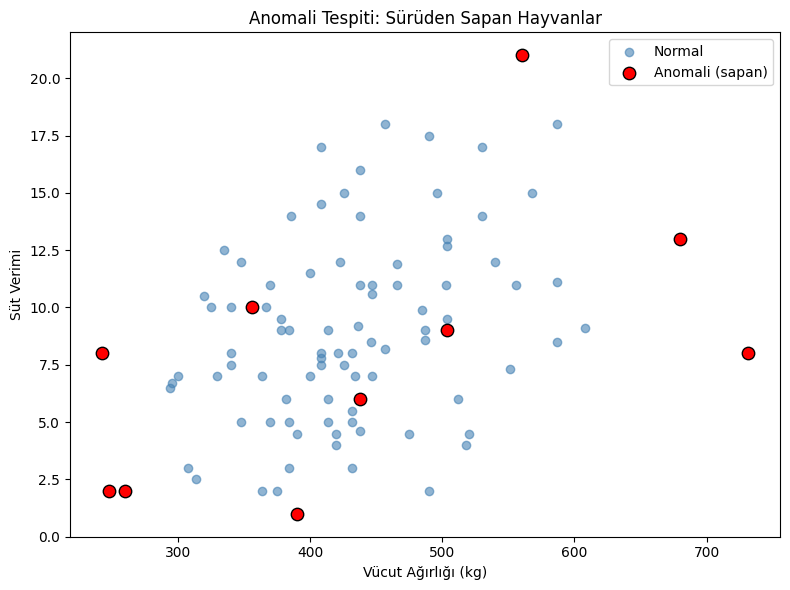

In [4]:
import matplotlib.pyplot as plt

normal = veri[veri["anomali"] == 1]
sapan = veri[veri["anomali"] == -1]

plt.figure(figsize=(8, 6))
plt.scatter(normal["Bodyweight"], normal["Total milk performance"],
            c="steelblue", label="Normal", alpha=0.6)
plt.scatter(sapan["Bodyweight"], sapan["Total milk performance"],
            c="red", label="Anomali (sapan)", edgecolors="black", s=80)
plt.xlabel("Vücut Ağırlığı (kg)")
plt.ylabel("Süt Verimi")
plt.title("Anomali Tespiti: Sürüden Sapan Hayvanlar")
plt.legend()
plt.tight_layout()
plt.show()

ısolation forest ile anamali tespiti yapmaya çalıştık ve gerçekten anamoli testinin ayırdıgı 10 hayvan gerçekten sorunlu hayvanlar ve bunları grafikleştirip göstermek isitedim .grafikte sapan 10 hayvanı bulmuş göstermiş olduk.


ANALİZ:

Sağdaki iki kırmızı (700+ kg) — en ağır hayvanlar, kümeden kopmuş.


Soldaki üç kırmızı (250-260 kg, düşük verim) — en hafif ve az verimli olanlar, sol alt köşede.


Üstteki kırmızı (yüksek verim ~21) — verim olarak zirvede, tek başına.

Kapanış — Anomali Tespiti

Bu notebook'ta, verim tahmininden farklı olarak bir hedef tahmin etmedik; bunun
yerine sürüden istatistiksel olarak sapan hayvanları otomatik bulduk.

**İzlenen adımlar**
1. Rwanda verisinden 4 anlamlı sayısal sütun seçme (ağırlık, yem, verim, süt günü)
2. Isolation Forest modeliyle sapan hayvanları tespit etme (contamination=0.1)
3. 96 hayvandan 10 sapanı işaretleme ve inceleme
4. Sapanları grafik üzerinde (kırmızı) normal hayvanlardan (mavi) ayırt etme

**Bulgular**
Model, sürünün genelinden belirgin biçimde ayrılan hayvanları yakaladı: çok ağır
(700+ kg), çok hafif (250 kg civarı), aşırı yem tüketen veya sıra dışı verim/süt
günü kombinasyonuna sahip olanlar. Grafikte bu hayvanların mavi kümenin dışında,
kenarlarda yer aldığı net görüldü.



****Önemli not:** Anomali "hasta" veya "sorunlu" demek değildir; yalnızca
"istatistiksel olarak farklı" demektir. Model, insana "bu hayvanlar dikkat çekici,
kontrol edilmeli" der — teşhis koymaz.**

**Projedeki karşılığı:** Bu yöntem, projede "şu hayvanın ölçümleri sürüden sapıyor,
kontrol edilmeli" şeklinde bir erken uyarı özelliği olarak kullanılabilir.




In [5]:
import joblib

joblib.dump(model, "anomali_modeli.pkl")
print("Anomali modeli kaydedildi: anomali_modeli.pkl")

# Kayıtlı modeli tek bir hayvanda test edelim
ornek = veri[["Bodyweight", "DM served", "Total milk performance", "daysinmilk"]].iloc[[30]]
sonuc = model.predict(ornek)
print("\n30 numaralı hayvan (731 kg):", "ANOMALİ" if sonuc[0] == -1 else "normal")

Anomali modeli kaydedildi: anomali_modeli.pkl

30 numaralı hayvan (731 kg): ANOMALİ


Bu modelim de güzel çalıştıgı için ve proje de kullanabileceğim için .joblib ile.pkl ye kaydediyoruz.
